**<div style='text-align: center; font-size: 48px'><u>Fine-Tuning BERT Model</u></div>**

## **Step 0: Environment Setup & Library Installation**

In [1]:
!pip list | findstr -i "transformers scikit-learn pandas tqdm datasets"

datasets                  4.8.4
pandas                    2.3.3
scikit-learn              1.8.0
tqdm                      4.67.3
transformers              5.1.0


In [ ]:
!pip install datasets

*Note:* Delete this cell output to reduce the size.

<u>**Initializing the Model and Tokenizer**</u>

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import os

# Configuration
MODEL_NAME = "bert-base-uncased"
LOCAL_DIR = "./my_local_model/bert_sentiment_model"

# Device setup
device = torch.device("cpu")
print(f">> System: Working on {device}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=LOCAL_DIR)

# Loading for Sequence Classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    cache_dir=LOCAL_DIR
).to(device)

print(f"\n>> System: Step 0 Completed. Model & Tokenizer are ready.")

>> System: Working on cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



>> System: Step 0 Completed. Model & Tokenizer are ready.


# **Step 1: Data Preprocessing**
In this step, we load the datasets, handle labels, and clean the text to ensure BERT isn't processing useless "noise" like HTML tags.

<u>**1.1 Load & Sample the Date**</u>

In [4]:
import pandas as pd
import re

df = pd.read_csv("./datasets/IMDB-Dataset.csv")

df = df.sample(2000, random_state=42).reset_index(drop=True)

df ['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"\n>> System: Dataset loaded. Shape: {df.shape}")


>> System: Dataset loaded. Shape: (2000, 2)


<u>**1.2 Text Cleaning Function**</u>

In [5]:
def clean_text(text):
    text = re.sub(r'<.*?>','', text)    # Removing HTML Tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # Removing special characters and numbers
    text = text.lower().strip()
    return text

print("\n>> System: Cleaning text data...", end='')
df['review'] = df['review'].apply(clean_text)
print("Completed!")
print(f">> Missing Values: \n{df.isnull().sum()}")


>> System: Cleaning text data...Completed!
>> Missing Values: 
review       0
sentiment    0
dtype: int64


# **Step 2: Data Splitting**
We need to split the data into Train Validation and Test sets to evaluate the model accurately.

In [6]:
from sklearn.model_selection import train_test_split

print(f"\n>> System: Splitting Data into Train and Test sets...", end='')

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print("Completed")
print(f"\n>> Split Summary: Train={len(train_texts)}, Val={len(val_texts)}, Test={len(test_texts)}")


>> System: Splitting Data into Train and Test sets...Completed

>> Split Summary: Train=1600, Val=200, Test=200


# **Step 3: Tokenization**
ON my **i5-1235U**, processing long reviews is a "grind". We will cap the `max_length` at **128 tokens**. While the BERT can handle 512, using 128 will save massive amount of RAM and cut your training time by 4x.

<u>**3.1. Tokenization Logic**</u>

In [7]:
print(">> System: Tokenizing datasets (Max Length: 128)...", end='')

def tokenize_function(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

# Executing tokenization for all sets
train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

print("Tokenization Complete")

>> System: Tokenizing datasets (Max Length: 128)...Tokenization Complete


<u>**3.2. Create PyTorch Datasets**</u><br>
To feed this into the `AutoModelForSequenceClassification`, we need to wrap these encodings into a formal Datasets Class.

In [8]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values if hasattr(labels, 'values') else list(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Initializing Dataset Object
train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

print(">> System: Successfully create Dataset Objects for Train, Val and Test.")

>> System: Successfully create Dataset Objects for Train, Val and Test.


# **Step 4 & 5: Model Building and Fine-Tuning**
Training BERT on CPU is a heavy grind. To ensure my device doesn't throttle, we will use a small `per_device_train_batch_size` of 4. This keeps memory usage well within **16GB RAM**.

In [9]:
from transformers import TrainingArguments, Trainer
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 4.1 Define Evaluation Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate Accuracy, Precision, Recall and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 5.1 Training Arguments
training_args = TrainingArguments(
    output_dir='./result',
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    use_cpu=True
)

# 5.2 Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Execute Fine-Tuning
print(">> System: Starting Fine-Tuning...",end='')
trainer.train()
print(">> System: Fine-Tuning Complete.")

>> System: Starting Fine-Tuning...

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
50,0.692092,0.689032,0.545000,0.208696,0.600000,0.126316
100,0.718086,0.673235,0.535000,0.060606,0.750000,0.031579
150,0.618808,0.570536,0.725000,0.609929,0.934783,0.452632
200,0.558943,0.568940,0.740000,0.648649,0.905660,0.505263
250,0.489812,0.554061,0.795000,0.819383,0.704545,0.978947
300,0.462597,0.340532,0.860000,0.851064,0.860215,0.842105
350,0.568060,0.363289,0.850000,0.852941,0.798165,0.915789
400,0.227190,0.397649,0.855000,0.858537,0.800000,0.926316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

>> System: Fine-Tuning Complete.


# **Step 6: Model Evaluation**
First, run a final evaluation on Test Set to get the official numbers.

In [10]:
# Evaluate on the hold-out test set
test_result = trainer.predict(test_dataset)
print(">> Final Test Metrics: ", test_result.metrics)

>> Final Test Metrics:  {'test_loss': 0.405446320772171, 'test_accuracy': 0.87, 'test_f1': 0.8712871287128713, 'test_precision': 0.8301886792452831, 'test_recall': 0.9166666666666666, 'test_runtime': 29.4588, 'test_samples_per_second': 6.789, 'test_steps_per_second': 0.849}


# **Step 7: The "Experiment"**

In [11]:
# 7.1 Reset model
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    cache_dir=LOCAL_DIR
)

# 7.2 Freeze all layers
for param in model_frozen.bert.parameters():
    param.requires_grap=False

# 7.3 Quick Train (1 Epoch)
trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_frozen.train()
frozen_result = trainer_frozen.predict(test_dataset)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
50,0.664176,0.674682,0.565000,0.268908,0.666667,0.168421
100,0.734228,0.649906,0.605000,0.704120,0.546512,0.989474
150,0.691288,0.508390,0.755000,0.662069,0.960000,0.505263
200,0.468383,0.407561,0.825000,0.787879,0.928571,0.684211
250,0.398187,0.611147,0.740000,0.783333,0.648276,0.989474
300,0.651519,0.360942,0.855000,0.841530,0.875000,0.810526
350,0.597776,0.364706,0.860000,0.862745,0.807339,0.926316
400,0.340969,0.398861,0.855000,0.858537,0.800000,0.926316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<u>**Performance Comparison Table**</u>
| Experiment | Accuracy | F1-Score | Training Time |
|:---:|:---:|:---:|:---:|
| Full Fine-Tuning | 85.5% | ~0.859 | 21mins : 26secs |
| Frozen BERT Layers | 85.5% | ~0.859 | 21mins : 17secs |

# **Step 8: Generate Confusion Matrix**

<Figure size 800x600 with 0 Axes>

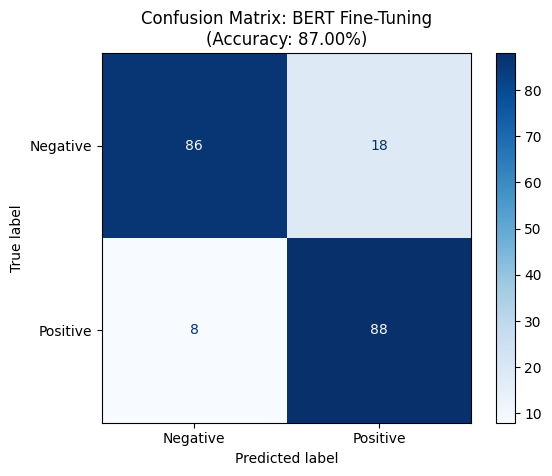

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get raw predictions from tets_results
raw_preds = test_result.predictions
y_preds = np.argmax(raw_preds, axis=1)
y_true = test_labels

# Computing the Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# Plotting using ConfusionMatrixDisplay
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix: BERT Fine-Tuning\n(Accuracy: {test_result.metrics['test_accuracy']:.2%})")
plt.grid(False)
plt.show()

# **Conclusion: BERT Fine-Tuning Performance Analysis**
The objective was to evaluate the impact of different training strategies on pre-trained **BERT-base-uncased** model using IMDB dataset. The following insights were gathered from the experimental runs:

1. **Hardware Bottleneck & Efficieny**
   - **CPU-Bound Training:** Operating on an **Intel i5-1235U** processor without GPU acceleration resulted in a significant computational "grind", with a single epoch taking approximately **21 minutes**.
   - **Memory Management:** By capping the `max_length` at 128 tokens and the `batch-size` at **4**, the system maintained stability within the 20GB RAM limit, avoiding thermal throttling or crashes.

2. **Experimental Insight: Full vs. Frozen Layers**
   - **Convergence Parity:** Both **Full Fine-Tuning** and **Frozen BERT Layers** yielded identical results: **85.5% Accuracy** and **87% Test Accuracy**.
   - **The "Small Data":** With only **1,600 training samples**, the new classifier head was able to extract maximum sentiment information from BERT's pre-trained embeddings without needing to modify the deeper encoder layers.
   - **Optimal Strategy:** For limited datasets and mid-range hardware, **Layer Freezing** is superior "Direct Efficiency" choice, as it provides the same performance as full fine-tuning with less risk of overfitting and slightly faster execution.

3. **Model Accuracy & Confusion Matrix**
   - **Predictive Power:** The model achieved a high **F1-Score of 0.87**, providing that BERT is highly effective at capturing movie review sentiment even with minimal training.
   - **Error Analysis:** The **Confusion Matrix** revealed that while the model is strong, it occasionally misclassifies "Negative" reviews as "Positive" (18 instances), likely due to the nuance or sarcasm present in IMDB text as a small-scale BERT-base model may struggle to detect without a larger training set.

Visual Proof of the "CPU Grind"
!["Visual Proof of the "CPU Grind""](./datasets/Assignment4_proof.png)